In [1]:
import sys
import os
import pytest

from tqdm.notebook import tqdm, trange
import jax
import jax.tree as jtu
import jax.numpy as np
import jax.random as jr
from jax import Array
from jax.flatten_util import ravel_pytree
import equinox as eqx
from zodiax.diffops import hessian
from zodiax.optimisation import eigen_projection

from optax import sgd, adam
import optimistix as optx

import amigo as amg
import dorito as drt
from dorito.model_fits import PointResolvedFit as prf
from dorito.model_fits import ResolvedOIFit
from dorito.model_fits import _OIFit
from dorito.models import ResolvedAmigoModel
from dorito.models import ResolvedDiscoModel
from dorito.bases import ImageBasis
from dorito.models import BaseModeller
from dorito.stats import disco_regularised_loss_fn


from kneed import KneeLocator

import dLux.utils as dlu

# matplotlib configs
from matplotlib import pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

plt.style.use(["science", "bright", "no-latex"])
new_rcParams = {
    "image.cmap": "inferno",
    "font.family": "serif",
    "image.origin": "lower",
    "figure.dpi": 300,
    "font.size": 8,
    "xtick.direction": "out",
    "ytick.direction": "out",
}
plt.rcParams.update(new_rcParams)

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

from frito.autoencoder.ae_utils import load_classes_from_file as lcf, run_svd
from frito import (
    TransformedResolvedDiscoModel as TRDM,
    AutoencoderBasis,
    TransformedResolvedOIFit as TROIF,
    PointResolvedOIFit as PROIF,
    PointResolvedDiscoModel as PRDM,
)
from frito.jax_gaussian import gaussian_filter

In [2]:
master_key = jr.key(0)
main_data_path = "_data"
autoencoder_data_path = os.path.join(main_data_path, "autoencoder")
main_trained_model_path = os.path.join(autoencoder_data_path, "trained_models")
main_svd_path = os.path.join(autoencoder_data_path, "svd")
training_data_path = os.path.join(autoencoder_data_path, "training_data")
emnist_path = os.path.join(training_data_path, "emnist.npz")
mnist_path = os.path.join(training_data_path, "mnist.npz")
ppd_51_path = os.path.join(training_data_path, "fake_intensity_PPDs_51x51.npz")

main_out_path = "_output"
main_model_struct_path = "src/frito/autoencoder/model_structures"

ppd_51x51_data = np.load(ppd_51_path)
test_51x51_data = ppd_51x51_data["x_test"]

disco_HD100546_path = os.path.join(
    main_data_path, "jwst", "HD100546", "disco", "cal_vis_HD-100546.npy"
)
disco_HD135344B_path = os.path.join(
    main_data_path, "jwst", "HD135344B", "disco", "cal_vis_HD135344B.npy"
)
disco_PDS70_path = os.path.join(
    main_data_path, "jwst", "PDS70", "disco", "bgmask_cal_vis_pds70.npy"
)

In [3]:
disco_PDS70 = np.load(disco_PDS70_path, allow_pickle=True).item()
disco_HD100546 = np.load(disco_HD100546_path, allow_pickle=True).item()
disco_HD135344B = np.load(disco_HD135344B_path, allow_pickle=True).item()

In [4]:
model_key, master_key = jr.split(master_key, 2)
model_type = "PPD"
i = 16
model_names = [
    "0_0",
    "0_2",
    "1_0",
    "1_2",
    "2_0",
    "2_1",
    "2_2",
    "3_0",
    "3_1",
    "3_2",
    "4_0",
    "4_1",
    "4_2",
    "7_0",
    "7_1",
    "7_2",
    "7_4",
    "7_5",
    "8_0",
    "8_2",
    "8_3",
    "8_4",
    "8_5",
    "8_6",
]
model_name = model_names[i]
model_struct_path = os.path.join(
    main_model_struct_path, f"model_{model_name}.py"
)
trained_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_best.eqx"
)
autoencoder_classes = lcf(model_struct_path)
autoencoder = autoencoder_classes["autoencoder"](key=model_key)
base_autoencoder = eqx.tree_deserialise_leaves(trained_model_path, autoencoder)

print(f"Model: {model_name}")
print(f"Model Struct: {model_struct_path}")
print(f"Trained Model Path: {trained_model_path}")
print(f"Autoencoder Classes: {autoencoder_classes}")

Model: 7_4
Model Struct: src/frito/autoencoder/model_structures/model_7_4.py
Trained Model Path: _data/autoencoder/trained_models/PPD/7_4_best.eqx
Autoencoder Classes: {'autoencoder': <class 'model_7_4.autoencoder'>, 'decoder': <class 'model_7_4.decoder'>, 'encoder': <class 'model_7_4.encoder'>}


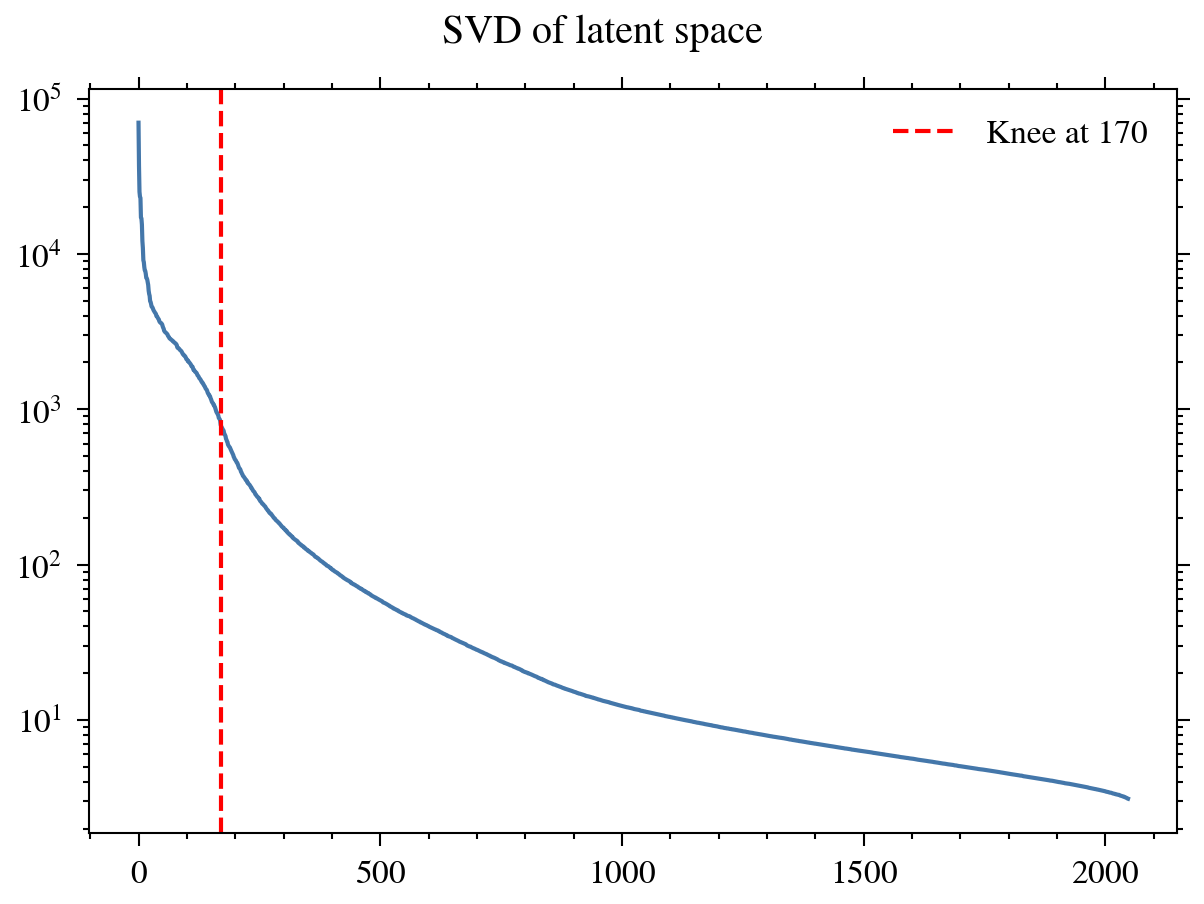

SVD Path: _data/autoencoder/svd/PPD_model_7_4_svd.npz
Knee at 170


In [5]:
svd_path = os.path.join(
    main_svd_path, f"{model_type}_model_{model_name}_svd.npz"
)
svd = np.load(svd_path)

k1 = KneeLocator(
    np.arange(len(svd["s"])),
    svd["s"],
    curve="convex",
    direction="decreasing",
    online=True,
)

fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
fig.suptitle("SVD of latent space")
ax.plot(svd["s"], marker=",")
ax.axvline(k1.knee, color="r", linestyle="--", label=f"Knee at {k1.knee}")
ax.legend()
ax.set_yscale("log")
plt.show()

print(f"SVD Path: {svd_path}")
print(f"Knee at {k1.knee}")

In [6]:
tmp_keys = jr.split(master_key, 3)
suture_keys = tmp_keys[:2]
master_key = tmp_keys[2]

new_encode_in = base_autoencoder.modules[0].layers[-1].in_features
new_encode_out = int(k1.knee)
new_encode_latent_weights = (
    base_autoencoder.modules[0].layers[-1].weight[:new_encode_out, :]
)
new_encode_latent_biases = (
    base_autoencoder.modules[0].layers[-1].bias[:new_encode_out]
)
new_encode_linear = eqx.nn.Linear(
    in_features=new_encode_in, out_features=new_encode_out, key=suture_keys[0]
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.weight, new_encode_linear, new_encode_latent_weights
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_encode_linear, new_encode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers[-1],
    base_autoencoder,
    trained_new_encode_linear,
)


def embed(X, knee, m, s, v):
    return (X - m[:knee]) @ v[:knee, :knee].T / np.sqrt(s[:knee] ** 2 / knee)


embed_layer = eqx.nn.Lambda(
    lambda z: embed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers,
    sutured_ae_struct,
    sutured_ae_struct.modules[0].layers + [embed_layer],
)


def unembed(embedded, knee, m, s, v):
    return ((embedded) * np.sqrt(s[:knee] ** 2 / knee)) @ v[:knee, :knee] + m[
        :knee
    ]


unembed_layer = eqx.nn.Lambda(
    lambda z: unembed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers,
    sutured_ae_struct,
    [unembed_layer] + sutured_ae_struct.modules[1].layers,
)

new_decode_out = sutured_ae_struct.modules[1].layers[2].out_features
new_decode_in = int(k1.knee)
new_decode_latent_weights = (
    sutured_ae_struct.modules[1].layers[2].weight[:, :new_decode_in]
)
new_decode_latent_biases = sutured_ae_struct.modules[1].layers[2].bias
new_decode_linear = eqx.nn.Linear(
    in_features=new_decode_in, out_features=new_decode_out, key=suture_keys[1]
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.weight, new_decode_linear, new_decode_latent_weights
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_decode_linear, new_decode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers[2],
    sutured_ae_struct,
    trained_new_decode_linear,
)

sutured_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_Rbest.eqx"
)
sutured_ae = eqx.tree_deserialise_leaves(sutured_model_path, sutured_ae_struct)
print(f"Suture Model Path: {sutured_model_path}")

def sum2unity(X):
    pix_sum = np.sum(X, axis=(1,2), keepdims=True)
    norm_pix = X/pix_sum
    return norm_pix

sum2unity_layer     = eqx.nn.Lambda(lambda z: sum2unity(z))
norm_sutured_ae     = eqx.tree_at(
        lambda m: m.modules[1].layers,
        sutured_ae,
        sutured_ae.modules[1].layers + [sum2unity_layer]
)

# encoder, decoder = sutured_ae.modules
encoder, decoder = norm_sutured_ae.modules

Suture Model Path: _data/autoencoder/trained_models/PPD/7_4_Rbest.eqx


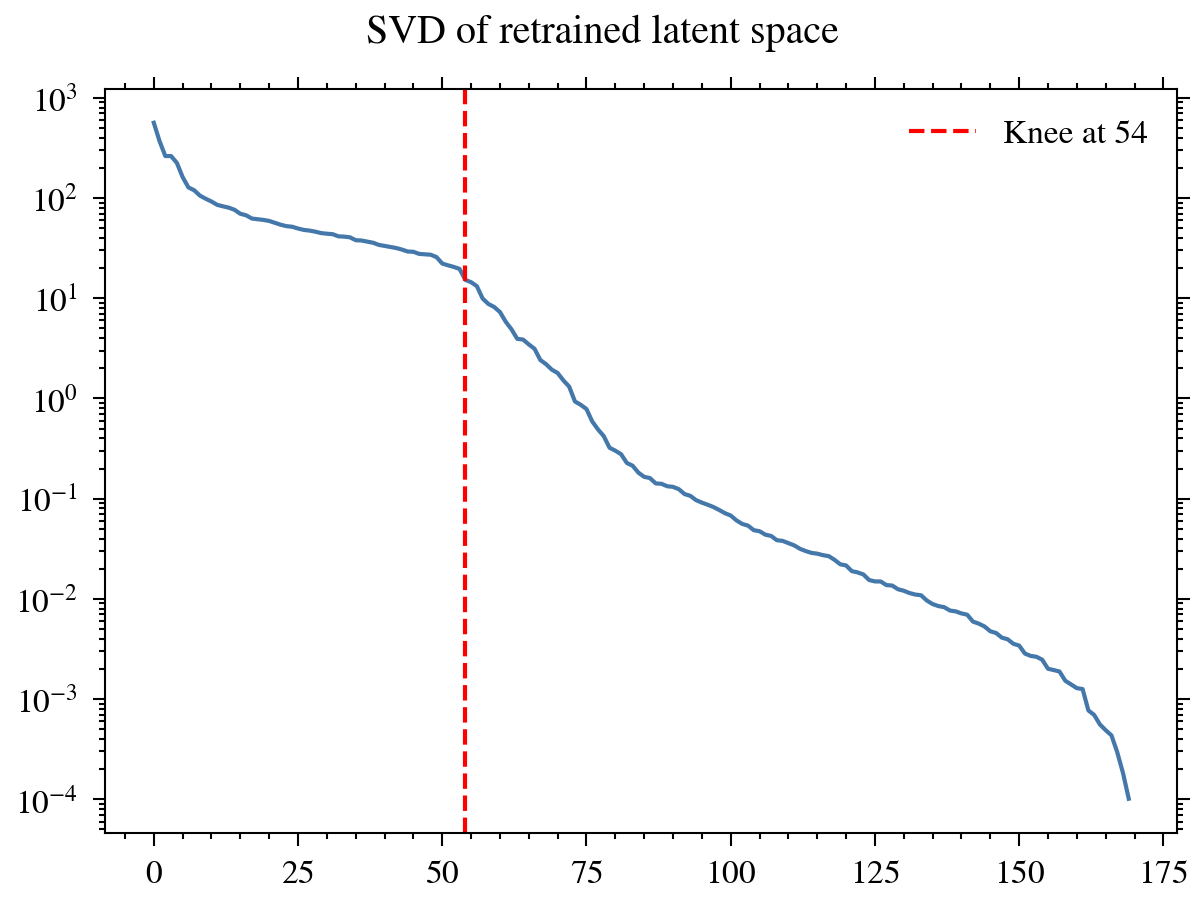

SVD Path: _data/autoencoder/svd/PPD_retrain_model_7_4_svd.npz
Knee at 54


In [7]:
svd2_path = os.path.join(
    main_svd_path, f"{model_type}_retrain_model_{model_name}_svd.npz"
)
svd2 = np.load(svd2_path)
k2 = KneeLocator(
    np.arange(len(svd2["s"])),
    svd2["s"],
    curve="convex",
    direction="decreasing",
    online=True,
)

fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
fig.suptitle("SVD of retrained latent space")
ax.plot(svd2["s"], marker=",")
ax.axvline(k2.knee, color="r", linestyle="--", label=f"Knee at {k2.knee}")
ax.legend()
ax.set_yscale("log")
plt.show()

print(f"SVD Path: {svd2_path}")
print(f"Knee at {k2.knee}")

In [186]:
def embed2(X, m, s, v):
    return (X - m) @ v.T / np.sqrt(s ** 2 / 170)


embed_layer2 = eqx.nn.Lambda(
    lambda z: embed2(z, svd2['mean'], svd2['s'], svd2['v'])
)
norm2_sutured_ae = eqx.tree_at(
    lambda m: m.modules[0].layers,
    norm_sutured_ae,
    norm_sutured_ae.modules[0].layers + [embed_layer2],
)


def unembed2(embedded, m, s, v):
    return ((embedded) * np.sqrt(s ** 2 / 170)) @ v + m


unembed_layer2 = eqx.nn.Lambda(
    lambda z: unembed2(z, svd2['mean'], svd2['s'], svd2['v'])
)
norm2_sutured_ae = eqx.tree_at(
    lambda m: m.modules[1].layers,
    norm2_sutured_ae,
    [unembed_layer2] + norm2_sutured_ae.modules[1].layers,#[1:],
)
encoder, decoder = norm2_sutured_ae.modules

In [187]:
# encoder, decoder = norm_sutured_ae.modules
encoder, decoder = norm2_sutured_ae.modules

Text(0.5, 1.0, 'Initial Distribution | Sum: 1.0')

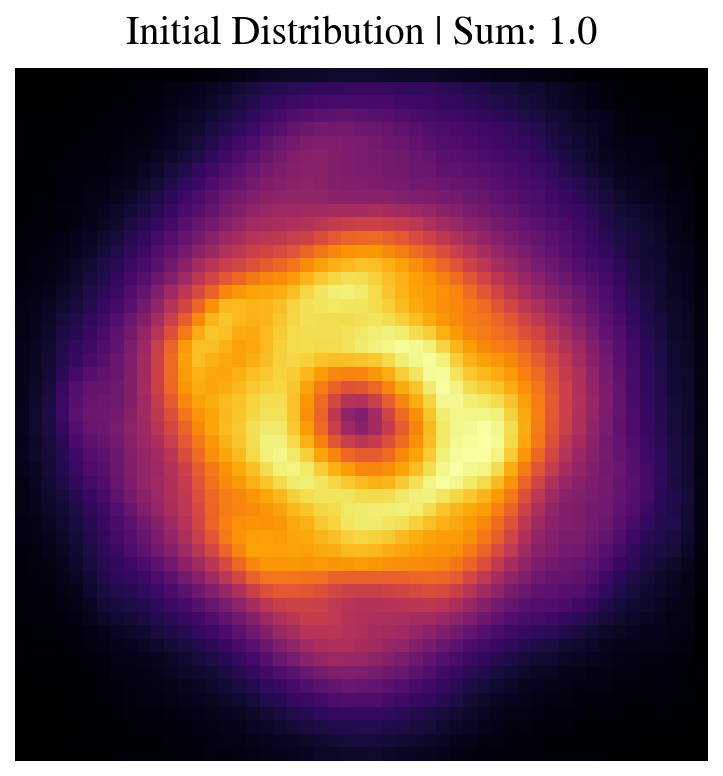

In [10]:
init_latent = np.zeros((170,))
init_dist = decoder(init_latent)
init_dist = init_dist[0]
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(init_dist)
ax.set_axis_off()
ax.set_title(f"Initial Distribution | Sum: {np.sum(init_dist)}")

In [11]:
for key, oi_data in disco_PDS70['F380M'].items():
    print(key)

u
v
vis_mat
phi_mat
K_vis_mat
K_phi_mat
parang
wavel
O_vis
O_phi
O_vis_cov
O_phi_cov
O_vis_mat
O_phi_mat
O_vis_eigv
O_phi_eigv
disco_vis_mat
disco_phi_mat
K_vis
K_vis_cov
K_phi
K_phi_cov
vis
vis_cov
phi
phi_cov


In [12]:
optics_diameter = 6.603464
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)
basis = AutoencoderBasis(norm2_sutured_ae)
# ois = [
#     PROIF(
#         oi_data,
#         key,
#         filter=key,
#     )
#     for key, oi_data in disco_PDS70.items()
# ]
key = 'F380M'
oi_data = disco_PDS70[key]
ois = [PROIF(oi_data, key, filter=key)]

In [13]:
model = PRDM(
    ois=ois,
    distribution=init_dist,
    basis=basis,
    contrast=0.045,
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    oversample=2.0,
)

PointResolvedOIFit(
  u=f32[1300],
  v=f32[1300],
  wavel=f32[],
  parang=f32[],
  vis=f32[349],
  d_vis=f32[349],
  phi=f32[349],
  d_phi=f32[349],
  vis_mat=f32[349,1300],
  phi_mat=f32[349,1300],
  key='F380M',
  filter='F380M'
)


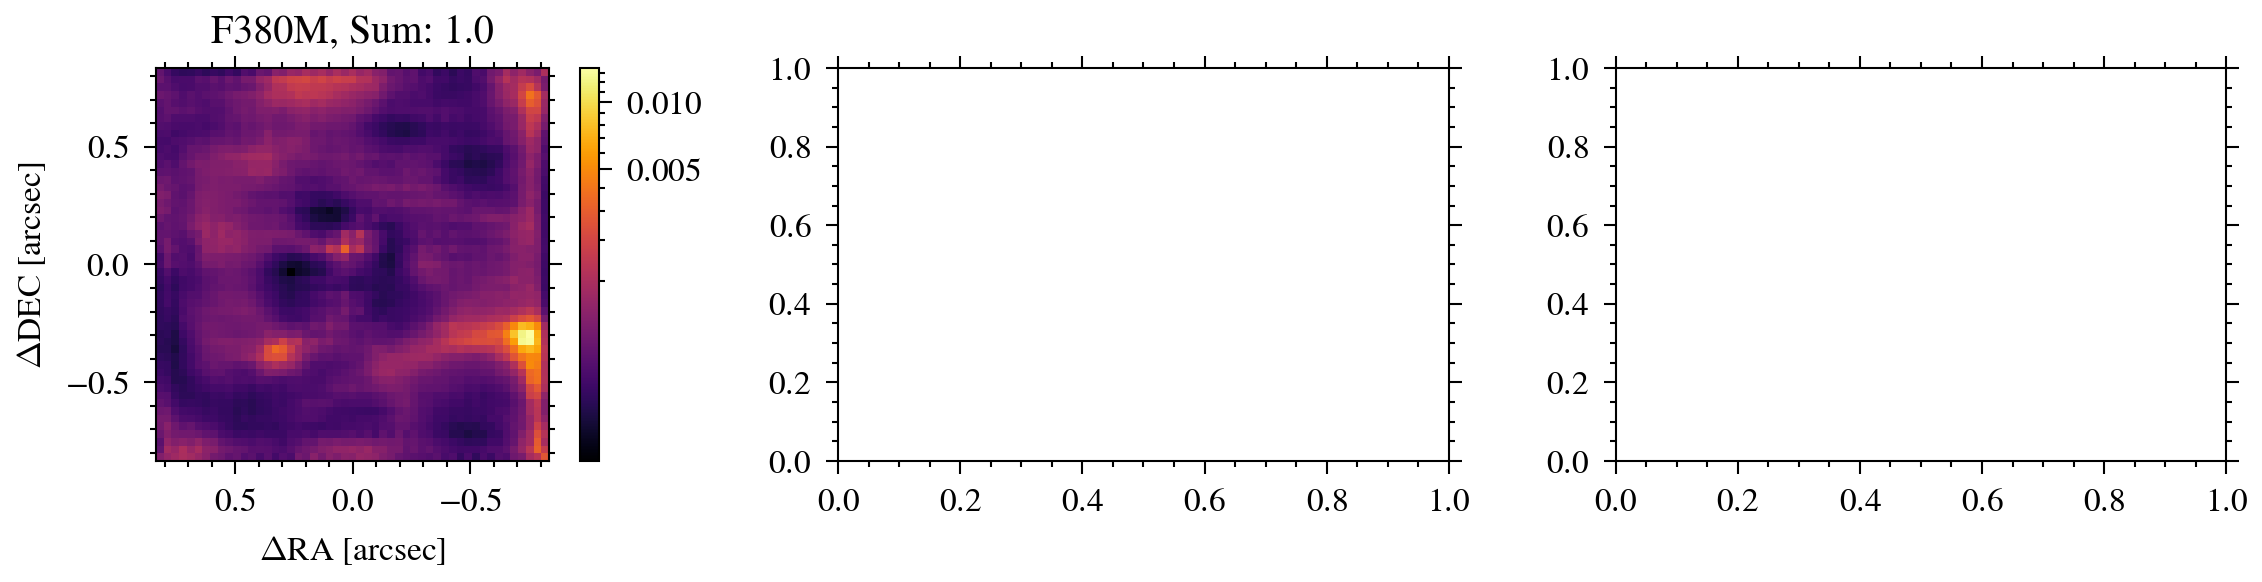

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(8, 2))

for idx, oi in enumerate(ois):
    print(oi)
    dist = model.get_distribution(oi, exponentiate=False)

    c0 = drt.plotting.plot_result(
        ax[idx],
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap=inferno,
        norm=mpl.colors.PowerNorm(0.3),
    )
    fig.colorbar(c0, ax=ax[idx])
    ax[idx].set(title=f"{oi.filter}, Sum: {dist.sum():.1f}")

plt.tight_layout()
plt.show()

In [15]:
def latent_gaussian_prior(model, exposure):
    """Unit Gaussian prior on the (SVD-normalised) latent for this exposure's filter."""
    z = model.params["log_dist"][exposure.get_key("log_dist")]
    return 0.5 * np.sum(z ** 2)

In [245]:
def norm_fn(model_params, args):
    params = model_params.params

    # NOTE: This normalisation won't work for an arbitrary basis!
    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            # distribution = 10**log_dist
            # log_dist = np.log10(distribution / distribution.sum())

            # basis = args["basis"]
            # window = args["window"]
            # distribution = 10 ** basis.from_basis(log_dist) * window
            # distribution = gaussian_filter(distribution, sigma=sig)
            # distribution += 1e-16 * ((window + 1) % 2)
            # log_dist = np.log10(distribution / distribution.sum())
            # log_dist = basis.to_basis(log_dist)
            # image, pix_sum = basis.from_basis(log_dist)
            # non_norm_image = image * pix_sum
            # blur_image = gaussian_filter(non_norm_image[0], sigma=0.00001, radius=1)
            # # # blur_image = blur_image / np.sum(blur_image)
            # log_dist = basis.to_basis(blur_image)
            params["log_dist"][k] = log_dist

    return model_params.set("params", params), args


def grad_fn(model, grads, args):

    # Reduce spectra gradients for the science exposures
    # if "spectra" in config.keys():
    #     grads = grads.multiply(spc_keys, 0.3)

    # if "fluxes" in config.keys():
    #     # grads = grads.multiply(flx_keys, 2)
    #     grads = grads.multiply(flx_keys, 5)
    # if "positions" in config.keys():
    #     # grads = grads.multiply(pos_keys, 0.5)
    #     grads = grads.multiply(pos_keys, 5)

    return grads, args

# ! PDS 70 FULL
# n_epoch = 5_000
# config = {
#     # "log_dist": adam(1e-3, 0),
#     "log_dist": adam(1.5e-4, 0),
#     "contrast": sgd(1e-8, 0),
#     # "contrast": sgd(2e-8, 100),
#     # "log_dist": adam(5e-3, 0),
# }
# ! PDS 70 F380M
# config = {
#     "log_dist": adam(5e-4, 0),
#     # "log_dist": adam(5e-4, 0), #"log_dist": adam(7.5e-4, 0),
#     "contrast": sgd(1e-5, 0),
#     # "contrast": sgd(2e-8, 100),
#     # "log_dist": adam(5e-3, 0),
# }
n_epoch = 50_000
config = {
    # "log_dist": adam(1e-3, 0),
    "log_dist": adam(1e-4, 0),#adam(7.5e-4, 0),#adam(1e-3, 0),
    "contrast": sgd(2.5e-9, 0),
    # "contrast": sgd(2e-8, 100),
    # "log_dist": adam(5e-3, 0),
}
# ! HD 135344B
# n_epoch = 20_000
# config = {
#     # "log_dist": adam(1e-3, 0),
#     "log_dist": adam(7.5e-5, 0),
#     "contrast": sgd(1e-10, 0),
#     # "contrast": sgd(2e-8, 100),
#     # "log_dist": adam(5e-3, 0),
# }

args = {
    "reg_dict": {
        'latent_gaussian_prior': (573, latent_gaussian_prior)
    },
    "basis": basis,
}
trainer = amg.fitting.Trainer(
    loss_fn=disco_regularised_loss_fn, norm_fn=norm_fn, grad_fn=grad_fn, cache="_data/amigo/fisher"
)
trainer = trainer.update_fishers(
    model=model,
    exposures=ois,
    parameters=[],
)
# trainer = trainer.populate_fishers(
#     model,
#     ois,
#     hessians=load_dict("_data/amigo/" + "jacobians.npy")["hessian"],
#     parameters=[p for p in config.keys()]
# )

  0%|          | 0/1 [00:00<?, ?it/s]

In [246]:
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    args=args,
)
# np.save('/Users/jonahgoldfine/Documents/Important Documents/packages/frito/_output/frito_deconv_10000.npy', result, allow_pickle=True)

  0%|          | 0/50000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 3,152.61
Estimated run time: 0:07:24
Full Time: 1:28:31
Final Loss: -2,502.74


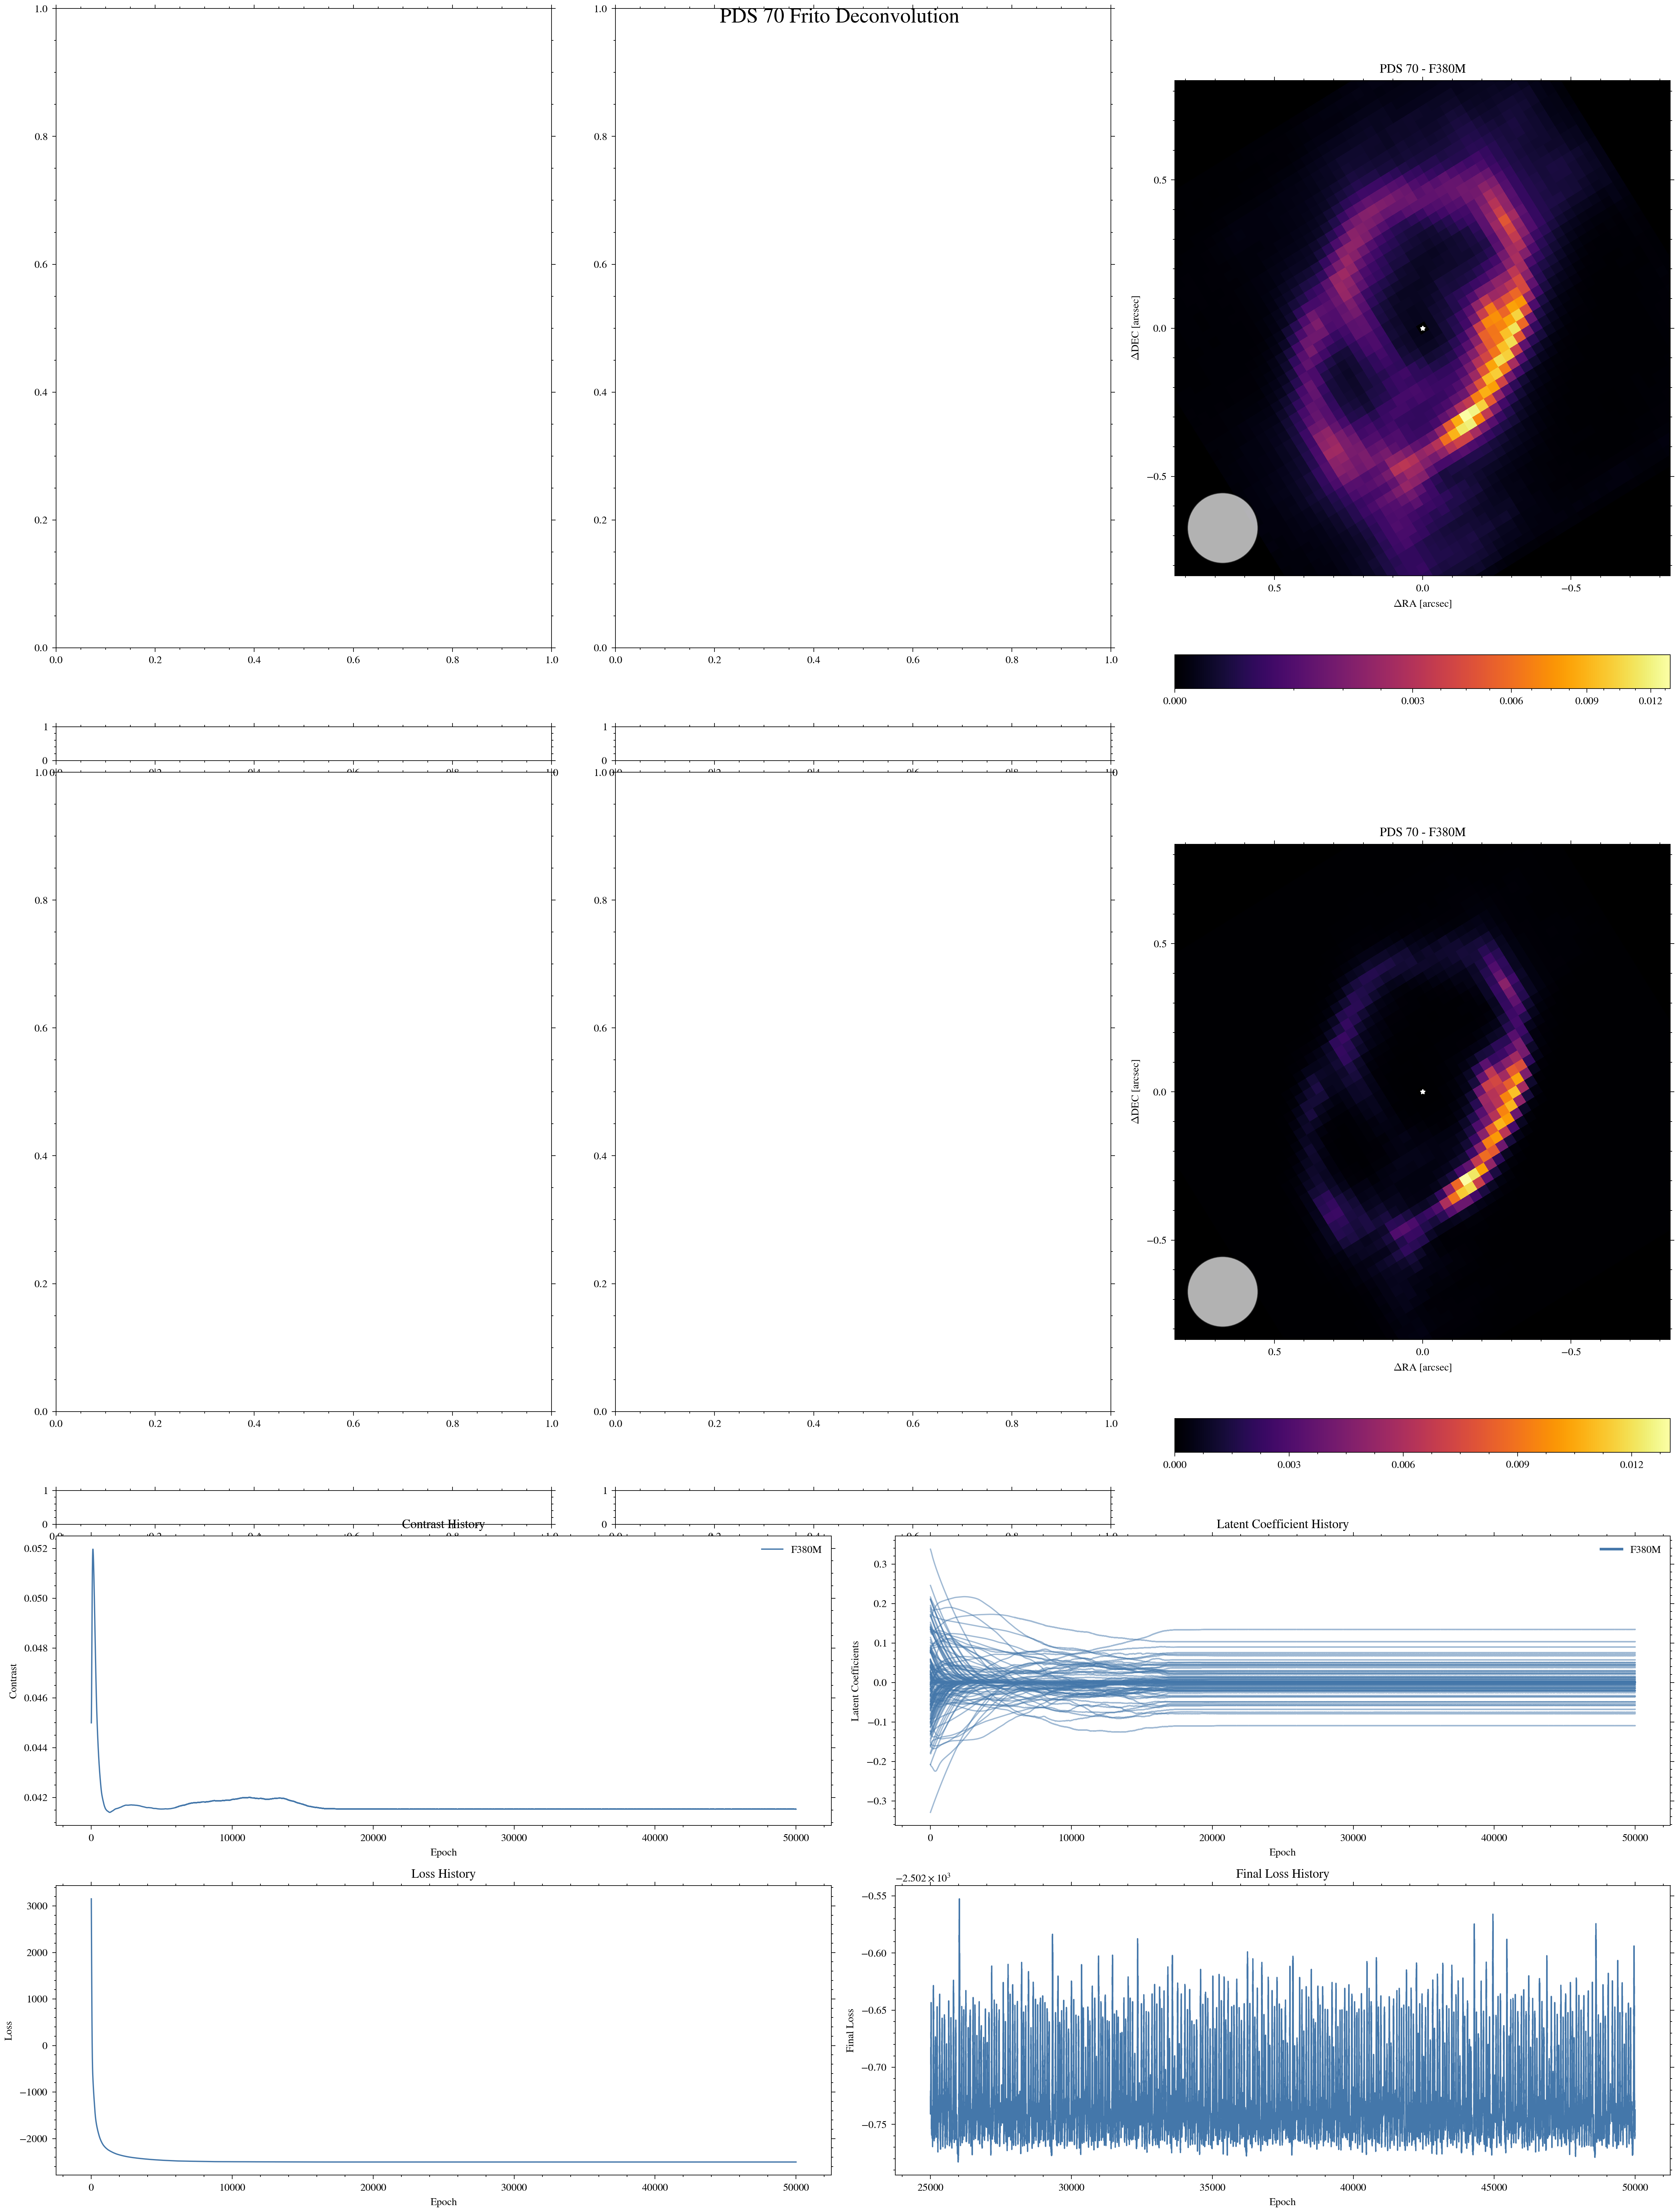

In [247]:
filters = ['F380M'] #['F480M', 'F430M', 'F380M']
final_loss_percent = 0.5

fig, ax_dict = plt.subplot_mosaic(
    [
        ['F480M',       'F480M',    'F430M',    'F430M',        'F380M',        'F380M'],
        ['F480M',       'F480M',    'F430M',    'F430M',        'F380M',        'F380M'],
        ['F480M',       'F480M',    'F430M',    'F430M',        'F380M',        'F380M'],
        ['F480M',       'F480M',    'F430M',    'F430M',        'F380M',        'F380M'],
        ['cb480',       'cb480',    'cb430',    'cb430',        'cb380',        'cb380'],
        ['F480M1',      'F480M1',   'F430M1',   'F430M1',       'F380M1',       'F380M1'],
        ['F480M1',      'F480M1',   'F430M1',   'F430M1',       'F380M1',       'F380M1'],
        ['F480M1',      'F480M1',   'F430M1',   'F430M1',       'F380M1',       'F380M1'],
        ['F480M1',      'F480M1',   'F430M1',   'F430M1',       'F380M1',       'F380M1'],
        ['1cb480',      '1cb480',   '1cb430',   '1cb430',       '1cb380',       '1cb380'],
        ['contrast',    'contrast', 'contrast', 'log_dist',     'log_dist',     'log_dist'],
        ['contrast',    'contrast', 'contrast', 'log_dist',     'log_dist',     'log_dist'],
        ['loss',        'loss',     'loss',     'final_loss',   'final_loss',   'final_loss'],
        ['loss',        'loss',     'loss',     'final_loss',   'final_loss',   'final_loss']
    ],
    figsize=(18, 24),
    # layout="constrained",
    height_ratios=[4, 4, 4, 4, 0.15, 4, 4, 4, 4, 0.15, 4, 4, 4, 4],
)

fig.suptitle('PDS 70 Frito Deconvolution', fontsize=16)

# Map filter name to its colorbar axis key
cbar_ax_keys = {'F480M': 'cb480', 'F430M': 'cb430', 'F380M': 'cb380'}
cbar1_ax_keys = {'F480M1':'1cb480', 'F430M1': '1cb430', 'F380M1': '1cb380'}

for ax_key in ax_dict.keys():
    if ax_key in filters:
        for oi in ois:
            if ax_key == oi.filter:
                dist = result.model(oi)
                n = dist.shape[0]

                disco_amp, disco_phase = np.split(oi(result.model), 2)

                vmax = float(np.nanmax(dist.at[n // 2, n // 2].set(np.nan)))

                c0 = drt.plotting.plot_result(
                    ax_dict[ax_key],
                    dist.at[n // 2, n // 2].set(np.nan),
                    pixel_scale=dlu.rad2arcsec(model.pscale_in),
                    cmap=inferno,
                    norm=mpl.colors.PowerNorm(.5, vmin=0, vmax=vmax),
                    roll_angle_degrees=-oi.parang,
                    diff_lim=dlu.rad2arcsec(oi.wavel / optics_diameter),
                )
                ax_dict[ax_key].scatter([0], [0], marker="*", color="white", s=10)
                ax_dict[ax_key].set(title=f"PDS 70 - {oi.key}")

                fig.colorbar(
                    c0,
                    cax=ax_dict[cbar_ax_keys[ax_key]],
                    orientation="horizontal",
                    ticks=mpl.ticker.MaxNLocator(nbins=5),
                )

    elif ax_key in cbar_ax_keys.values():
        pass  # populated above alongside its image panel

    elif ax_key == 'contrast':
        for filter in filters:
            ax_dict[ax_key].plot(result.history['contrast'][filter], label=filter)
            ax_dict[ax_key].set_title('Contrast History')
            ax_dict[ax_key].set_xlabel('Epoch')
            ax_dict[ax_key].set_ylabel('Contrast')
            ax_dict[ax_key].legend()

    elif ax_key == 'log_dist':
        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
        for i, filter in enumerate(filters):
            log_dist_history = result.history['log_dist'][filter]
            color = colors[i]
            ax_dict[ax_key].plot(log_dist_history, alpha=0.5, color=color)
            ax_dict[ax_key].plot([], [], color=color, label=filter, linewidth=2)
        ax_dict[ax_key].set_title('Latent Coefficient History')
        ax_dict[ax_key].set_xlabel('Epoch')
        ax_dict[ax_key].set_ylabel('Latent Coefficients')
        ax_dict[ax_key].legend()

    elif ax_key == 'loss':
        ax_dict[ax_key].plot(result.losses[0])
        ax_dict[ax_key].set_title('Loss History')
        ax_dict[ax_key].set_xlabel('Epoch')
        ax_dict[ax_key].set_ylabel('Loss')

    elif ax_key == 'final_loss':
        start = int(final_loss_percent * len(result.losses[0]))
        epochs = np.arange(start, len(result.losses[0]))
        ax_dict[ax_key].plot(epochs[0:-1], result.losses[0][start:-1])
        ax_dict[ax_key].set_title('Final Loss History')
        ax_dict[ax_key].set_xlabel('Epoch')
        ax_dict[ax_key].set_ylabel('Final Loss')
    else:
        for oi in ois:
            if ax_key == oi.filter+'1':
                dist = result.model(oi)
                n = dist.shape[0]

                disco_amp, disco_phase = np.split(oi(result.model), 2)

                vmax = float(np.nanmax(dist.at[n // 2, n // 2].set(np.nan)))

                c0 = drt.plotting.plot_result(
                    ax_dict[ax_key],
                    dist.at[n // 2, n // 2].set(np.nan),
                    pixel_scale=dlu.rad2arcsec(model.pscale_in),
                    cmap=inferno,
                    norm=mpl.colors.PowerNorm(1.0, vmin=0, vmax=vmax),
                    roll_angle_degrees=-oi.parang,
                    diff_lim=dlu.rad2arcsec(oi.wavel / optics_diameter),
                )
                ax_dict[ax_key].scatter([0], [0], marker="*", color="white", s=10)
                ax_dict[ax_key].set(title=f"PDS 70 - {oi.key}")

                fig.colorbar(
                    c0,
                    cax=ax_dict[cbar1_ax_keys[ax_key]],
                    orientation="horizontal",
                    ticks=mpl.ticker.MaxNLocator(nbins=5),
                )
fig.tight_layout()
for filter, cb_key in cbar_ax_keys.items():
    img_ax = ax_dict[filter]
    cb_ax  = ax_dict[cb_key]
    
    # Snap colorbar to just below its image panel
    img_pos = img_ax.get_position()
    cb_ax.set_position([
        img_pos.x0,
        img_pos.y0 - 0.05,   # how far below the image, in figure coords
        img_pos.width,
        0.015,               # colorbar height in figure coords
    ])
for filter, cb_key in cbar1_ax_keys.items():
    img_ax = ax_dict[filter]
    cb_ax  = ax_dict[cb_key]
    
    # Snap colorbar to just below its image panel
    img_pos = img_ax.get_position()
    cb_ax.set_position([
        img_pos.x0,
        img_pos.y0 - 0.05,   # how far below the image, in figure coords
        img_pos.width,
        0.015,               # colorbar height in figure coords
    ])

In [228]:
np.std(model.params['log_dist']['F380M'])

Array(0.10131014, dtype=float32)

In [20]:
image_hist = jax.vmap(decoder)(np.array(result.history['log_dist']['F380M']))

In [ ]:
from celluloid import Camera

In [ ]:
image_hist_squeeze = image_hist[:,0,:,:]


  0%|          | 0/10001 [00:00<?, ?it/s]

MovieWriter ffmpeg unavailable; using Pillow instead.


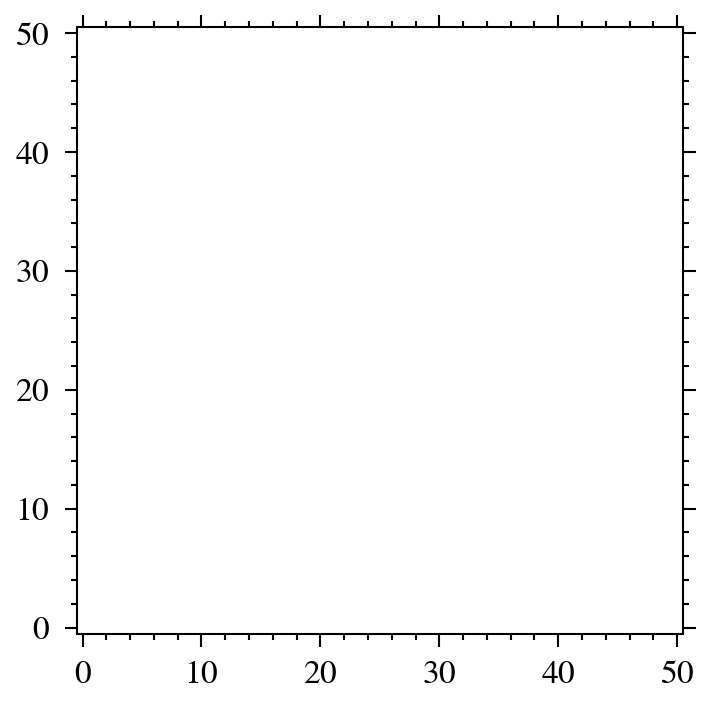

In [ ]:
fig, ax = plt.subplots(1,1)
camera = Camera(fig)
for j in trange(0, 10001, 10):
    ax.imshow(image_hist_squeeze[j], vmin=image_hist_squeeze.min(), vmax=image_hist_squeeze.max())
    camera.snap()
anim = camera.animate(5)
anim.save('/Users/jonahgoldfine/Documents/Important Documents/packages/frito/_output/10000e_F380M_blur_skip10.gif')

In [ ]:
forecast = ois[0](model)

In [ ]:
ois[0]

PointResolvedOIFit(
  u=f32[1300],
  v=f32[1300],
  wavel=f32[],
  parang=f32[],
  vis=f32[349],
  d_vis=f32[349],
  phi=f32[349],
  d_phi=f32[349],
  vis_mat=f32[349,1300],
  phi_mat=f32[349,1300],
  key='F380M',
  filter='F380M'
)

In [ ]:
from amigo.vis_analysis import AmigoOIData

In [ ]:
ois[0]

PointResolvedOIFit(
  u=f32[1300],
  v=f32[1300],
  wavel=f32[],
  parang=f32[],
  vis=f32[349],
  d_vis=f32[349],
  phi=f32[349],
  d_phi=f32[349],
  vis_mat=f32[349,1300],
  phi_mat=f32[349,1300],
  key='F380M',
  filter='F380M'
)

In [ ]:
nvis = ois[0].vis.shape[0]
vis, phi = forecast[:nvis], forecast[nvis:]
sim_data = AmigoOIData({
    "u": ois[0].u,
    "v": ois[0].v,
    "wavel": ois[0].wavel,
    "parang": ois[0].parang,
    "vis": vis,
    "d_vis": ois[0].d_vis,
    "phi": phi,
    "d_phi": ois[0].d_phi,
    "vis_mat": ois[0].vis_mat,
    "phi_mat": ois[0].phi_mat,
    "key": "F380M",
    "filter": "F380M"    
}
)

KeyError: 'O_vis'

In [ ]:
forecast = ois[0](model)
def oi_log_likelihood_forecast(model, oi, forecast):
    """Compute a Gaussian negative log-likelihood for OI data.

    Parameters
    ----------
    model : object
        Model object callable as ``oi(model)`` to return model predictions.
    oi : object
        Object exposing ``vis``, ``phi``, ``d_vis`` and ``d_phi`` arrays.
    """
    data = forecast
    err = np.concatenate([oi.d_vis, oi.d_phi])
    model_vis = oi(model)

    residual = data - model_vis
    nll = np.sum(0.5 * (residual / err) ** 2 + np.log(err * np.sqrt(2 * np.pi)))

    return nll

def disco_regularised_loss_forecast_fn(model, exposure, forecast, args={"reg_dict": {}}):
    """Compute a regularised loss for interferometric (DISCO) data.

    The returned value mirrors other loss wrappers and returns a scalar plus
    an empty tuple for compatibility with calling code.
    """

    # regular likelihood term
    likelihood = oi_log_likelihood(model, exposure)

    # grabbing and exponentiating log distributions
    prior = apply_regularisers(model, exposure, args)

    return likelihood + prior, ()

def neg_log_post_forecast(x,forecast):
        new_log_dist = dict(model.params["log_dist"])
        new_log_dist[filter_name] = x["log_dist"]
        new_contrast = dict(model.params["contrast"])
        new_contrast[filter_name] = x["contrast"]
        new_params = dict(model.params)
        new_params["log_dist"] = new_log_dist
        new_params["contrast"] = new_contrast
        m = eqx.tree_at(lambda mm: mm.params, model, new_params)
        loss, _ = oi_log_likelihood_forecast(m, oi, forecast)
        return loss

# BFGS

In [26]:
from frito import disco_regularised_loss_forecast_fn, oi_log_likelihood_forecast

In [248]:
args = {
    "reg_dict": {
        'latent_gaussian_prior': (573, latent_gaussian_prior)
    },
    "basis": basis,
}
def run_filter_bfgs(model, oi, filter_name, args,  max_steps=500, rtol=1e-8, atol=1e-8):
    x_init = {
        "log_dist": model.params["log_dist"][filter_name],
        "contrast": model.params["contrast"][filter_name],
    }

    def neg_log_post(x):
        new_log_dist = dict(model.params["log_dist"])
        new_log_dist[filter_name] = x["log_dist"]
        new_contrast = dict(model.params["contrast"])
        new_contrast[filter_name] = x["contrast"]
        new_params = dict(model.params)
        new_params["log_dist"] = new_log_dist
        new_params["contrast"] = new_contrast
        m = eqx.tree_at(lambda mm: mm.params, model, new_params)
        loss, _ = disco_regularised_loss_fn(m, oi, args)
        return loss
    


    

    
    forecast = np.array(oi(model))

    def neg_log_post_forecast(x,forecast):
        new_log_dist = dict(model.params["log_dist"])
        new_log_dist[filter_name] = x["log_dist"]
        new_contrast = dict(model.params["contrast"])
        new_contrast[filter_name] = x["contrast"]
        new_params = dict(model.params)
        new_params["log_dist"] = new_log_dist
        new_params["contrast"] = new_contrast
        m = eqx.tree_at(lambda mm: mm.params, model, new_params)
        loss, _ = disco_regularised_loss_forecast_fn(m, oi, forecast, args)
        return loss
    # DIAGNOSTICS
    f0 = float(neg_log_post(x_init))
    g0 = jax.grad(neg_log_post)(x_init)
    g0_flat, _ = ravel_pytree(g0)
    print(f"[{filter_name}] loss={f0:.3e}, "f"‖grad‖_inf={float(np.max(np.abs(g0_flat))):.3e}")

    # HESSIAN
    
    print(f"[{filter_name}] computing Hessian...")
    H, _ = hessian(lambda x: neg_log_post_forecast(x, forecast), x_init, nbatches=1, jit=True)
    def safe_fisher(H, floor_rel=1e-8):
        """Symmetrise H and reconstruct it with eigenvalues floored to be
        strictly positive. The result is PSD and safe to pass to eigen_projection."""
        H_sym = 0.5 * (H + H.T)
        vals, vecs = np.linalg.eigh(H_sym)
        floor = floor_rel * np.max(np.abs(vals))   # use abs in case max is negative
        vals_clipped = np.clip(vals, floor, None)
        return (vecs * vals_clipped) @ vecs.T
    H_safe = safe_fisher(H)
    P = eigen_projection(fmat=H_safe)

    X0, unravel = ravel_pytree(x_init)
    n = X0.size

    def project_fn(u):
        return X0 + P @ u
    
    # Projected loss for BFGS
    @jax.jit
    def projected_loss(u, _args):
        return neg_log_post(unravel(project_fn(u)))
    
    # running bfgs
    print(f"[{filter_name}] running BFGS in latent space...")
    solver = optx.BestSoFarMinimiser(
        optx.BFGS(rtol=rtol, atol=atol)
    )

    u0 = np.zeros(n)

    sol = optx.minimise(
        projected_loss, solver, u0,
        args=None,
        max_steps=max_steps,
        throw=False,
    )

    # project back into param space
    u_opt = sol.value
    x_opt = unravel(project_fn(u_opt))

    # ---- Diagnostics after ----
    f1 = float(neg_log_post(x_opt))
    g1 = jax.grad(neg_log_post)(x_opt)
    g1_flat, _ = ravel_pytree(g1)
    print(f"[{filter_name}] after:  loss={f1:.3e}, "
            f"‖grad‖_inf={float(np.max(np.abs(g1_flat))):.3e}, "
            f"steps={int(sol.stats['num_steps'])}, "
            f"result={optx.RESULTS[sol.result]}"
        )
    

    # Write back into model
    new_log_dist = dict(model.params["log_dist"])
    new_log_dist[filter_name] = x_opt["log_dist"]
    new_contrast = dict(model.params["contrast"])
    new_contrast[filter_name] = x_opt["contrast"]
    new_params = dict(model.params)
    new_params["log_dist"] = new_log_dist
    new_params["contrast"] = new_contrast
    new_model = eqx.tree_at(lambda mm: mm.params, model, new_params)

    return {
        "model": new_model,
        "x_opt": x_opt,
        "u_opt": u_opt,
        "loss_before": f0,
        "loss_after": f1,
        "grad_inf_before": float(np.max(np.abs(g0_flat))),
        "grad_inf_after": float(np.max(np.abs(g1_flat))),
        "H_before": H,
        "P": P,
        "X0": X0,
        "sol": sol,
    }



In [249]:
frito_model = result.model

In [250]:
first_bfgs = {}
for oi in ois:
    fname = oi.filter
    bfgs_results = run_filter_bfgs(frito_model, oi, fname, args,  max_steps=1000, rtol=1e-8, atol=1e-8)
    first_bfgs[fname] = bfgs_results

[F380M] loss=-2.503e+03, ‖grad‖_inf=8.092e+02
[F380M] computing Hessian...
[F380M] running BFGS in latent space...
[F380M] after:  loss=-2.503e+03, ‖grad‖_inf=4.349e+01, steps=79, result=


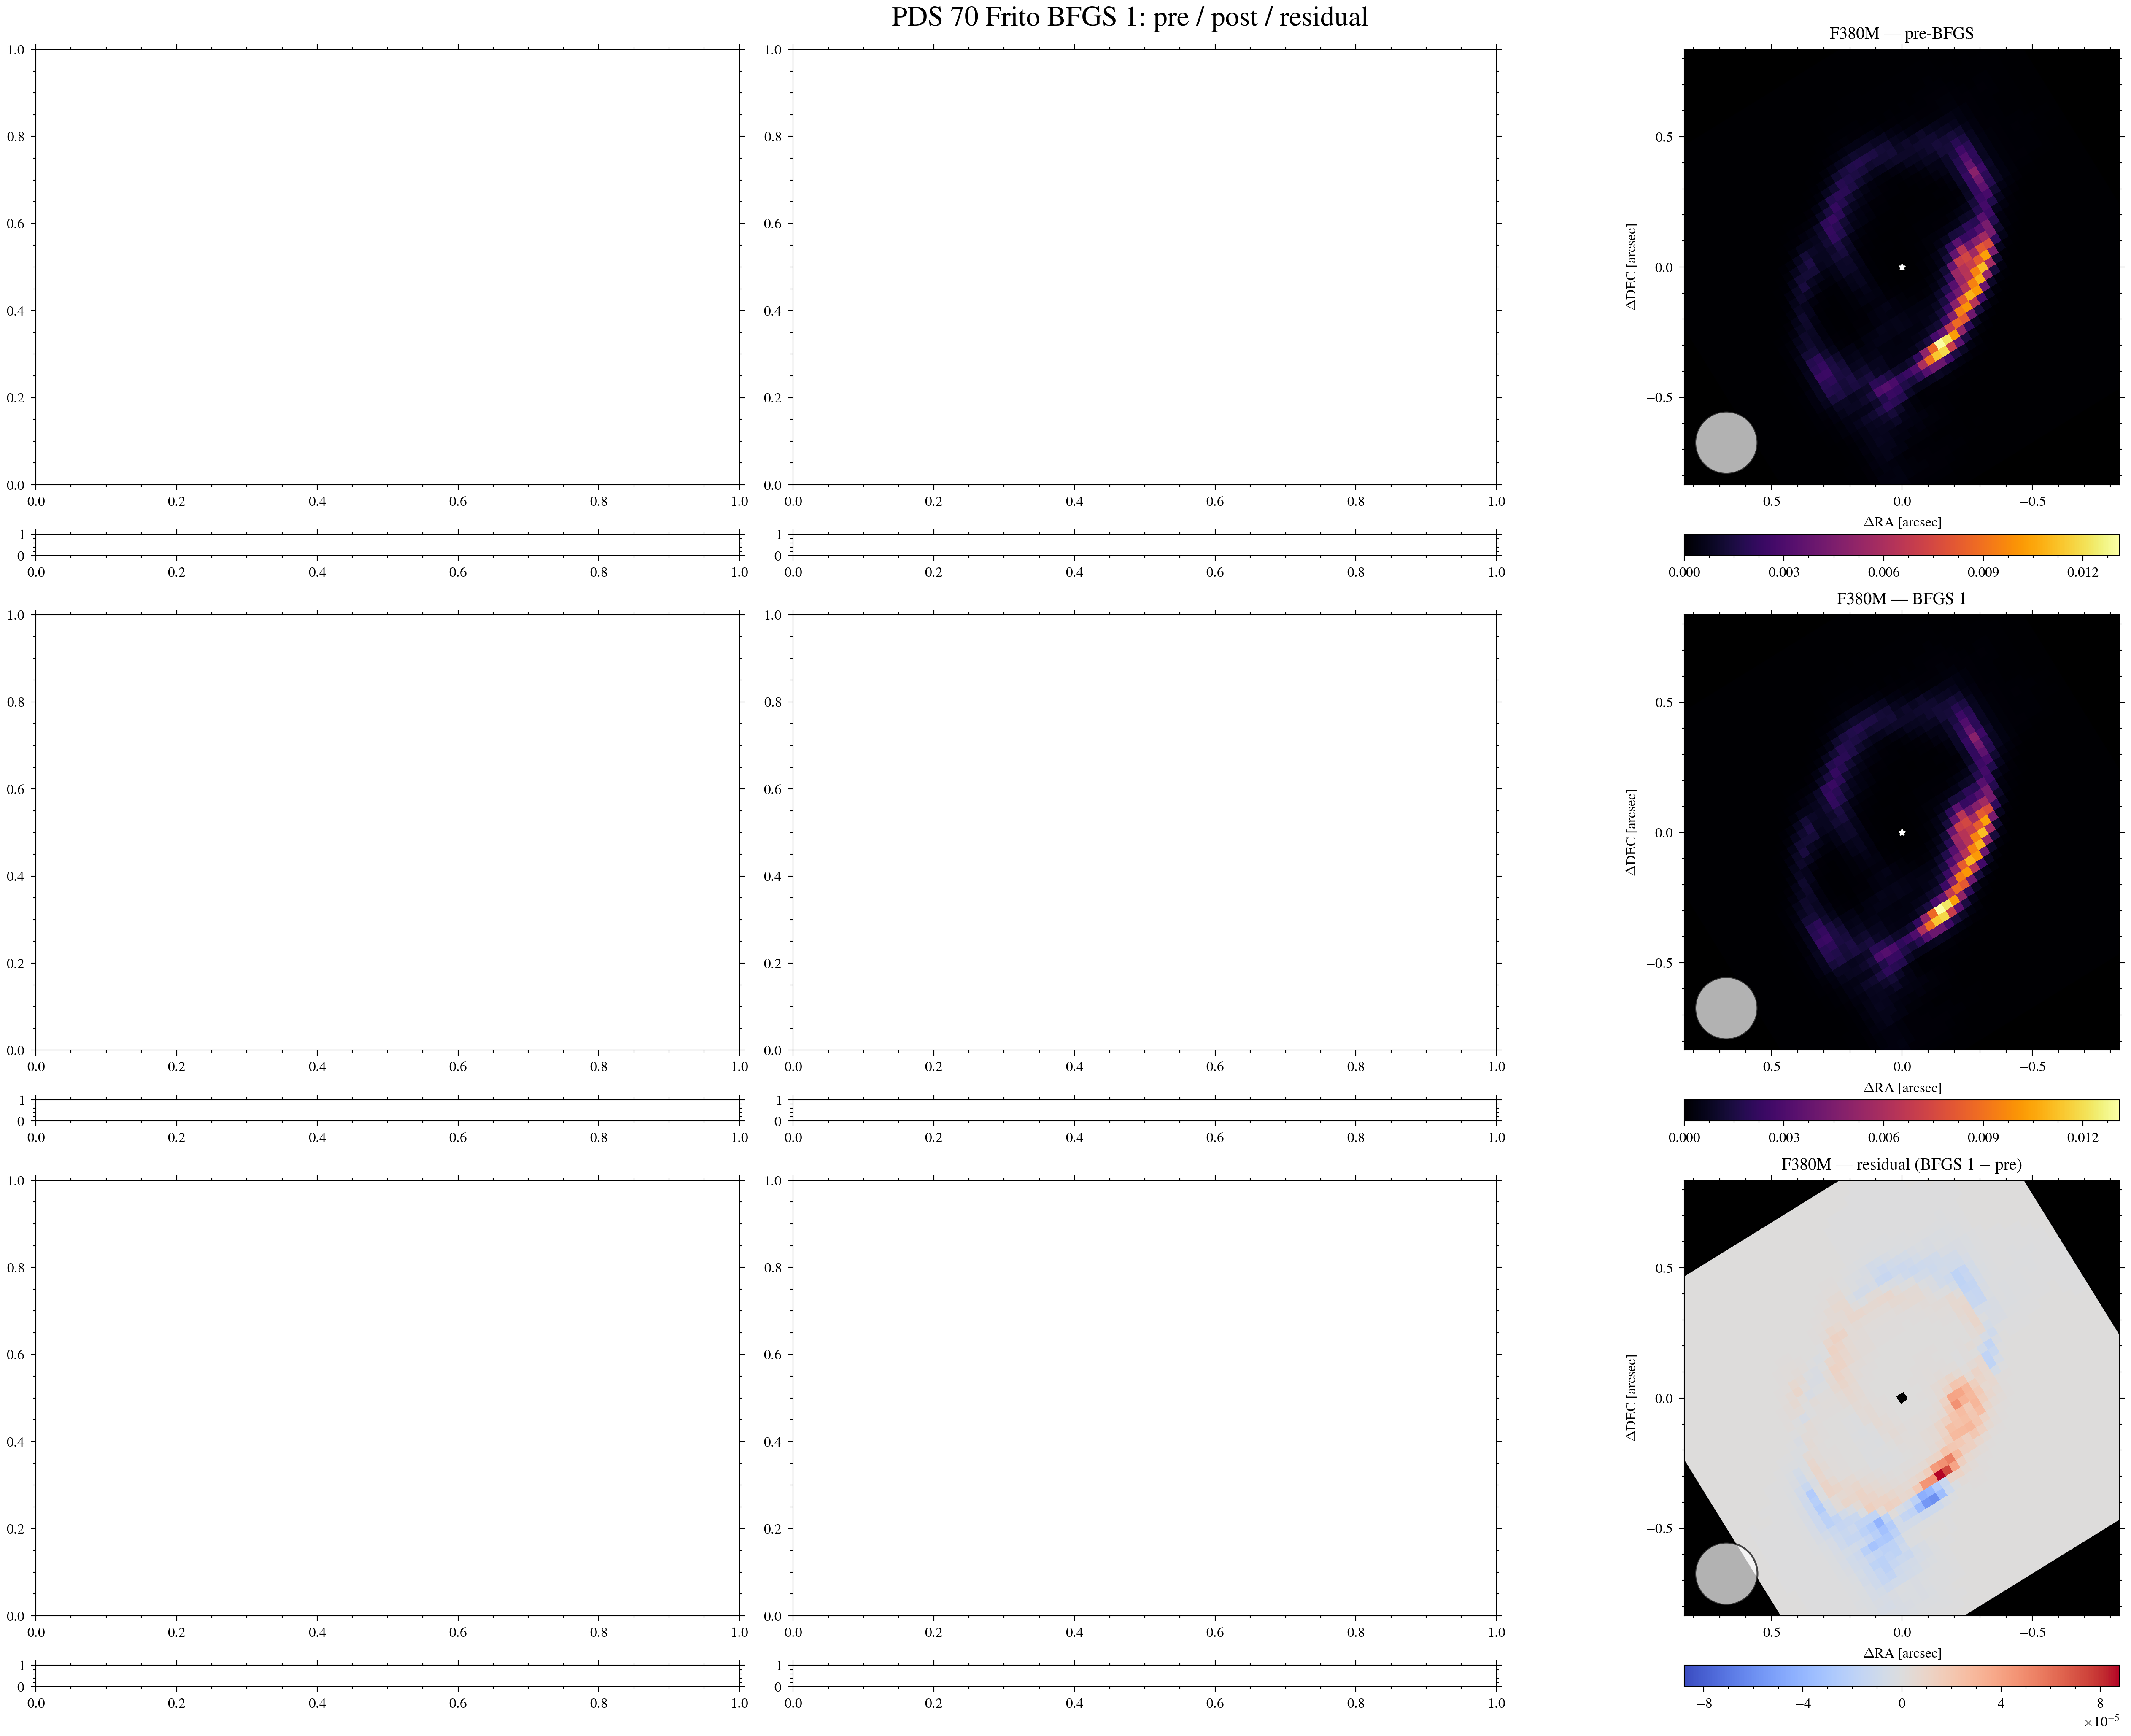

In [ ]:
filters = ['F380M'] #['F480M', 'F430M', 'F380M']

fig, ax_dict = plt.subplot_mosaic(
    [
        ['pre480',     'pre480',    'pre430',    'pre430',    'pre380',    'pre380'],
        ['pre480',     'pre480',    'pre430',    'pre430',    'pre380',    'pre380'],
        ['cb_pre480',  'cb_pre480', 'cb_pre430', 'cb_pre430', 'cb_pre380', 'cb_pre380'],
        ['post480',    'post480',   'post430',   'post430',   'post380',   'post380'],
        ['post480',    'post480',   'post430',   'post430',   'post380',   'post380'],
        ['cb_post480', 'cb_post480','cb_post430','cb_post430','cb_post380','cb_post380'],
        ['res480',     'res480',    'res430',    'res430',    'res380',    'res380'],
        ['res480',     'res480',    'res430',    'res430',    'res380',    'res380'],
        ['cb_res480',  'cb_res480', 'cb_res430', 'cb_res430', 'cb_res380', 'cb_res380'],
    ],
    figsize=(18, 14),
    height_ratios=[4, 4, 0.15, 4, 4, 0.15, 4, 4, 0.15],
)

fig.suptitle('PDS 70 Frito BFGS 1: pre / post / residual', fontsize=16)

for fname in filters:
    oi = next(o for o in ois if o.filter == fname)

    bfgs1_model = first_bfgs[fname]["model"]   # ← just grab it

    dist_pre = frito_model(oi)
    dist_post = bfgs1_model(oi)

    n = dist_pre.shape[0]
    # blank the central pixel as you were doing for the colorbar scale
    pre_plot = dist_pre.at[n // 2, n // 2].set(np.nan)
    post_plot = dist_post.at[n // 2, n // 2].set(np.nan)
    res_plot = post_plot - pre_plot

    # shared vmax for pre and post (same colour scale across the two)
    vmax = float(np.nanmax(np.array([np.nanmax(pre_plot), np.nanmax(post_plot)])))
    res_v = float(np.nanmax(np.abs(res_plot))) 

    common = dict(
        pixel_scale=dlu.rad2arcsec(frito_model.pscale_in),
        roll_angle_degrees=-oi.parang,
        diff_lim=dlu.rad2arcsec(oi.wavel / optics_diameter),
    )

    # --- pre ---
    c_pre = drt.plotting.plot_result(
        ax_dict[f'pre{fname[1:4]}'],
        pre_plot,
        cmap=inferno,
        norm=mpl.colors.PowerNorm(1, vmin=0, vmax=vmax),
        **common,
    )
    ax_dict[f'pre{fname[1:4]}'].scatter([0], [0], marker="*", color="white", s=10)
    ax_dict[f'pre{fname[1:4]}'].set(title=f"{fname} — pre-BFGS")
    fig.colorbar(c_pre, cax=ax_dict[f'cb_pre{fname[1:4]}'],
                 orientation="horizontal",
                 ticks=mpl.ticker.MaxNLocator(nbins=5))

    # --- post (BFGS 1) ---
    c_post = drt.plotting.plot_result(
        ax_dict[f'post{fname[1:4]}'],
        post_plot,
        cmap=inferno,
        norm=mpl.colors.PowerNorm(1, vmin=0, vmax=vmax),
        **common,
    )
    ax_dict[f'post{fname[1:4]}'].scatter([0], [0], marker="*", color="white", s=10)
    ax_dict[f'post{fname[1:4]}'].set(title=f"{fname} — BFGS 1")
    fig.colorbar(c_post, cax=ax_dict[f'cb_post{fname[1:4]}'],
                 orientation="horizontal",
                 ticks=mpl.ticker.MaxNLocator(nbins=5))

    # --- residual (signed, diverging cmap centred at 0) ---
    c_res = drt.plotting.plot_result(
        ax_dict[f'res{fname[1:4]}'],
        res_plot,
        cmap=coolwarm,
        norm=mpl.colors.Normalize(vmin=-res_v, vmax=res_v),
        **common,
    )
    ax_dict[f'res{fname[1:4]}'].scatter([0], [0], marker="*", color="black", s=10)
    ax_dict[f'res{fname[1:4]}'].set(title=f"{fname} — residual (BFGS 1 − pre)")
    fig.colorbar(c_res, cax=ax_dict[f'cb_res{fname[1:4]}'],
                 orientation="horizontal",
                 ticks=mpl.ticker.MaxNLocator(nbins=5))

fig.tight_layout()

# Snap each colorbar below its image
for short_filter in ['480', '430', '380']:
    for prefix in ['pre', 'post', 'res']:
        img_ax = ax_dict[f'{prefix}{short_filter}']
        cb_ax = ax_dict[f'cb_{prefix}{short_filter}']
        img_pos = img_ax.get_position()
        cb_ax.set_position([
            img_pos.x0,
            img_pos.y0 - 0.04,
            img_pos.width,
            0.012,
        ])

plt.show()

In [209]:
data=ppd_51x51_data['x_train']
batch_size=250

In [192]:
def encode_batch(batch):
    return jax.vmap(encoder)(batch)

latents2 = []
for i in range(0, len(data), batch_size):
    batch = data[i:i + batch_size]
    batch = batch.reshape(-1, 1, batch.shape[-1], batch.shape[-2])
    latents2.append(encode_batch(batch))
train_latents2 = np.concatenate(latents2)


In [193]:
best_latent = first_bfgs['F380M']['x_opt']['log_dist']

In [134]:
best_latent.shape

(170,)

In [194]:
distances = np.linalg.norm(train_latents2 - best_latent, axis=1)

In [195]:
sorted_dists=np.argsort(distances)

In [196]:
best_train_latent = train_latents2[sorted_dists[:-10]]

In [157]:
sorted_dists[0]

Array(4810, dtype=int32)

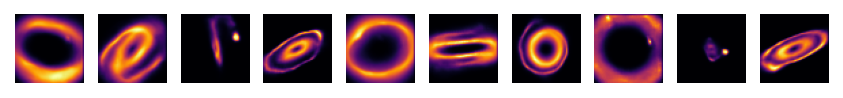

In [197]:
fig,axes = plt.subplots(1,10)
for i,ax in enumerate(axes):
    ax.imshow(decoder(best_train_latent[i])[0])
    ax.set_axis_off()

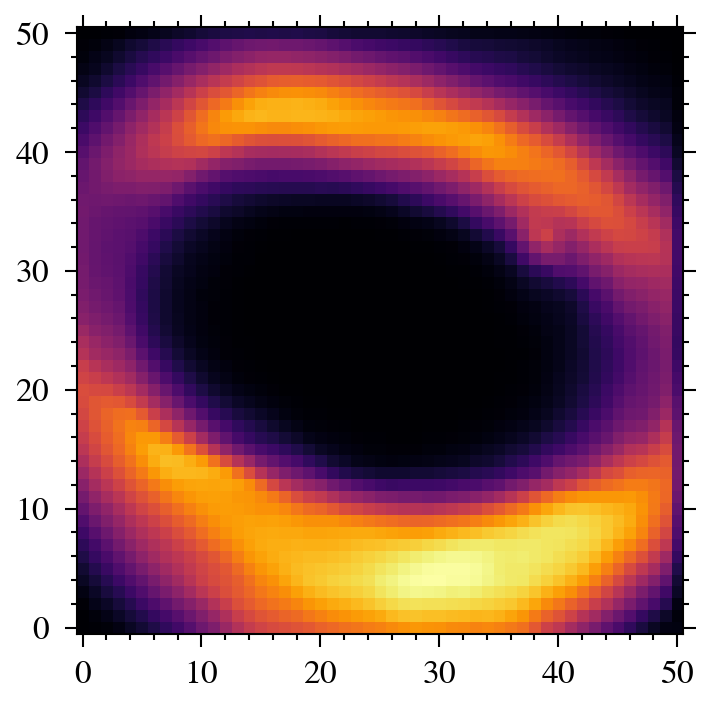

In [137]:
plt.imshow(decoder(best_train_latent)[0])

In [ ]:
i=100
i_coef = train_latents2[:,i]
print(f'mean: {np.mean(i_coef)}')
print(f'std: {np.std(i_coef)}')

mean: -17051.1171875
std: 21923.24609375


In [ ]:
i.mean(best_latent)

Array(-0.39333388, dtype=float32)

In [235]:
np.std(train_latents2)

Array(0.04175679, dtype=float32)

In [234]:
coefs_mean = np.mean(train_latents2,axis=0)
coefs_std = np.std(train_latents2, axis=0)

Text(0.5, 1.0, 'mean')

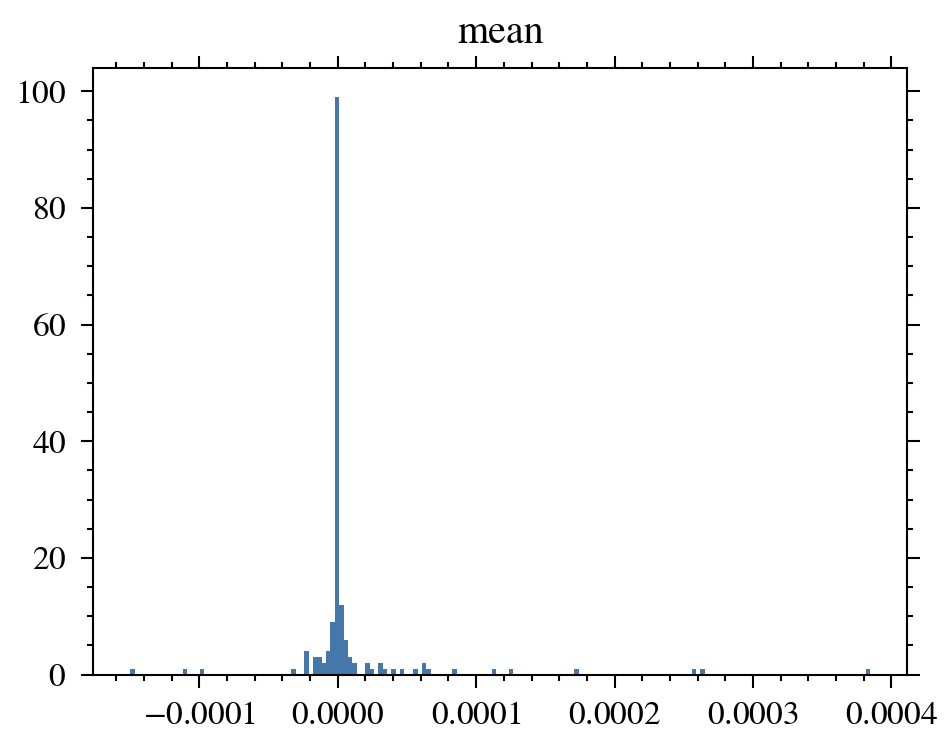

In [233]:
plt.hist(coefs_mean,bins=170)
plt.title('mean')

Text(0.5, 1.0, 'std')

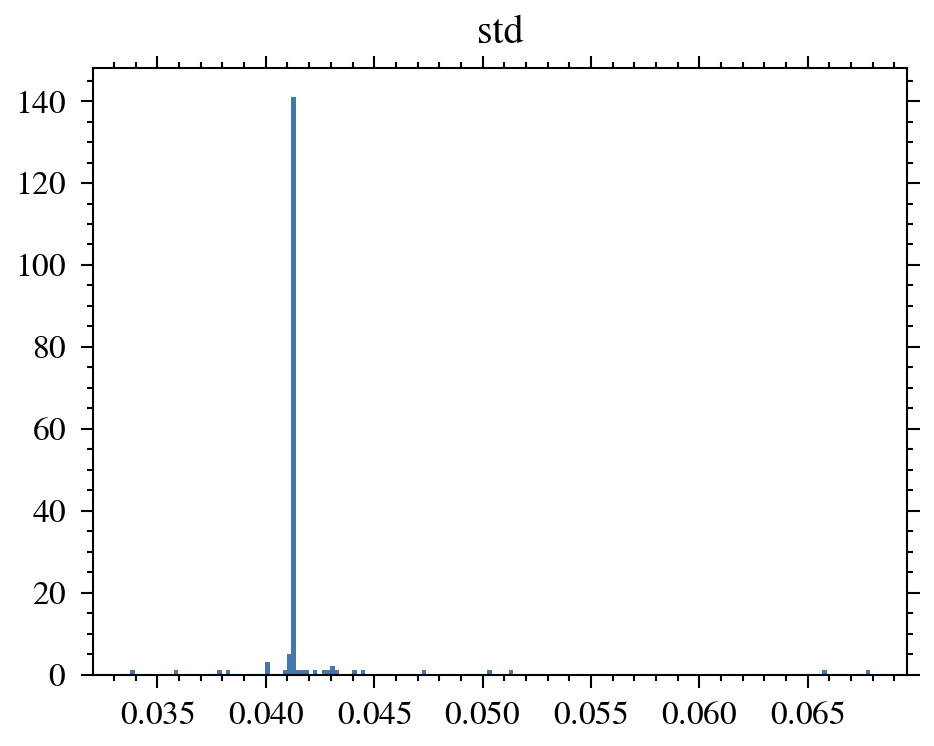

In [204]:
plt.hist(coefs_std, bins=170)
plt.title('std')

Array(1.6867561e+06, dtype=float32)